# TT-16 — Decision Tree Regressor: Bảng giá cước taxi NYC cho tổng đài

**Bài toán:** hãng taxi cần một **bảng giá ước tính** để tổng đài viên báo cho khách qua điện
thoại, trước khi điều xe. Ba yêu cầu nghiệp vụ bắt buộc:

```
① Tổng đài viên phải TRA ĐƯỢC nhanh, không dùng máy tính phức tạp
② Giá báo phải GIẢI THÍCH ĐƯỢC nếu khách thắc mắc
③ Sai số chấp nhận ±15%
```

→ Một cây quyết định **nông** (4–5 tầng) in ra thành **bảng tra** là sản phẩm phù hợp nhất —
model chính xác hơn nhưng không tra được bằng tay thì vô dụng ở bài toán này.

**Dữ liệu:** [NYC Yellow Taxi Trip Records](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)
tháng 1/2023 — hơn 3 triệu chuyến, lấy mẫu 200.000 dòng. Notebook này đi qua toàn bộ 12 bước
trong `README.md` + 3 phần mở rộng, với dữ liệu và số liệu **thật** (chạy lại được 100%).

## Decision Tree Regressor là gì

Giống cây phân loại (TT-02) nhưng lá trả về **SỐ TRUNG BÌNH** thay vì nhãn, và tiêu chí chia là
**giảm MSE** thay vì giảm Gini.

```
              Quãng đường > 5 km?
             ╱                  ╲
          KHÔNG                  CÓ
           ╱                      ╲
     Giờ cao điểm?          Quãng đường > 15 km?
      ╱        ╲                ╱          ╲
   45.000đ   62.000đ        180.000đ    310.000đ
   (lá = TRUNG BÌNH giá của các chuyến rơi vào nhánh này)
```

⚠️ **Đặc điểm phải hiểu:** cây hồi quy cho ra hàm **BẬC THANG**, không phải đường mượt. Số giá
trị đầu ra khác nhau **bằng đúng số lá**. Cây 8 lá chỉ báo được 8 mức giá — chứng minh trực quan
ở bước 8.

In [1]:
%matplotlib inline
import json
import time
import urllib.request
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
REPORTS_DIR = ROOT / "reports"
OUTPUTS_DIR = ROOT / "outputs"
for d in (DATA_DIR, MODELS_DIR, REPORTS_DIR, OUTPUTS_DIR):
    d.mkdir(exist_ok=True, parents=True)

RANDOM_STATE = 42
DATA_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
DATA_PARQUET = DATA_DIR / "yellow_tripdata_2023-01.parquet"
SAMPLE_SIZE = 200_000

RAW_COLS = ["tpep_pickup_datetime", "passenger_count", "trip_distance",
            "PULocationID", "DOLocationID", "payment_type", "fare_amount"]
FEATURES = ["trip_distance", "passenger_count", "PULocationID", "DOLocationID",
            "payment_type", "hour", "dow", "is_peak"]
TARGET = "fare_amount"
DISPATCH_DEPTH = 5
DISPATCH_MIN_LEAF = 500


def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def pct_within_band(y_true, y_pred, band=0.15):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float((np.abs(y_pred - y_true) / y_true <= band).mean() * 100)


def evaluate(y_true, y_pred):
    return {"MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred),
            "R2": float(r2_score(y_true, y_pred)), "trong_15%_%": pct_within_band(y_true, y_pred)}

## 1. Tải dữ liệu NYC Yellow Taxi, lấy mẫu 200.000 dòng

Tải file `parquet` chính thức tháng 1/2023 từ NYC TLC (cache lại vào `data/`), chỉ đọc các cột
cần thiết (tránh nạp cả 19 cột gốc, tiết kiệm RAM), rồi lấy mẫu ngẫu nhiên 200.000 dòng — dữ
liệu gốc hơn 3 triệu dòng là quá nặng để luyện tập lặp đi lặp lại.

In [2]:
if not DATA_PARQUET.exists():
    urllib.request.urlretrieve(DATA_URL, DATA_PARQUET)

df_full = pd.read_parquet(DATA_PARQUET, columns=RAW_COLS)
n_full = len(df_full)
df_raw = df_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Du lieu goc: {n_full:,} dong -> lay mau {len(df_raw):,} dong")
df_raw.head()

Du lieu goc: 3,066,766 dong -> lay mau 200,000 dong


,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount
0,2023-01-29 17:52:02,1.0,1.17,262,74,2,7.2
1,2023-01-08 15:57:24,1.0,0.90,229,237,2,6.5
2,2023-01-21 19:38:01,1.0,0.95,45,261,1,7.9
3,2023-01-23 16:07:31,5.0,0.88,237,141,1,16.3
4,2023-01-26 21:21:08,2.0,1.03,229,140,1,6.5


**Đọc kết quả:** file tháng 1/2023 có **3.066.766 dòng** — khớp với README ("1 tháng ≈ 3
triệu chuyến"). Lấy mẫu ngẫu nhiên (`random_state=42`, cố định để tái lập được) còn **200.000
dòng**, đủ nhẹ để chạy toàn bộ notebook trong vài chục giây nhưng vẫn đủ lớn để tin cậy thống
kê (mỗi lá của cây sau này sẽ dựa trên hàng trăm–hàng nghìn chuyến thật).

## 2. Làm sạch dữ liệu — 4 bước bắt buộc

```
1. LẤY MẪU (đã làm ở bước 1)
2. Loại chuyến vô lý: fare_amount <= 0, trip_distance <= 0 hoặc > 100 miles, passenger_count == 0
3. ⚠️ RÒ RỈ: KHÔNG dùng tip_amount, tolls_amount, total_amount làm đặc trưng (chỉ biết SAU chuyến
   đi) — chỉ đơn giản là KHÔNG đọc các cột này vào FEATURES (xem RAW_COLS ở trên: đã loại sẵn)
4. Tạo đặc trưng thời gian (bước 3 của notebook, ngay sau đây)
```

Ghi lại số dòng bị loại ở từng điều kiện của bước 2 (+ một điều kiện làm sạch bổ sung: loại các
mốc thời gian lỗi nhập liệu nằm ngoài tháng 1/2023, phát hiện khi khảo sát dữ liệu thô).

In [3]:
def clean_data(df):
    log_steps = []
    n0 = len(df)

    mask_fare = df["fare_amount"] > 0
    log_steps.append({"buoc": "Loai fare_amount <= 0 (huy/hoan tien)", "so_dong_bi_loai": int((~mask_fare).sum())})
    df = df[mask_fare]

    mask_dist = (df["trip_distance"] > 0) & (df["trip_distance"] <= 100)
    log_steps.append({"buoc": "Loai trip_distance <= 0 hoac > 100 miles", "so_dong_bi_loai": int((~mask_dist).sum())})
    df = df[mask_dist]

    mask_pax = df["passenger_count"].notna() & (df["passenger_count"] > 0)
    log_steps.append({"buoc": "Loai passenger_count == 0 hoac thieu", "so_dong_bi_loai": int((~mask_pax).sum())})
    df = df[mask_pax]

    mask_date = (df["tpep_pickup_datetime"] >= "2023-01-01") & (df["tpep_pickup_datetime"] < "2023-02-01")
    log_steps.append({"buoc": "Loai pickup ngoai thang 1/2023 (loi nhap lieu)", "so_dong_bi_loai": int((~mask_date).sum())})
    df = df[mask_date]

    return df.reset_index(drop=True), log_steps


n0 = len(df_raw)
df_clean, clean_log = clean_data(df_raw)
clean_table = pd.DataFrame(clean_log)
clean_table["so_dong_con_lai_sau_buoc"] = n0 - clean_table["so_dong_bi_loai"].cumsum()
print(f"Con lai {len(df_clean):,} / {n0:,} dong ({len(df_clean) / n0 * 100:.1f}%)")
clean_table

Con lai 188,224 / 200,000 dong (94.1%)


,buoc,so_dong_bi_loai,so_dong_con_lai_sau_buoc
0,Loai fare_amount <= 0 (huy/hoan tien),1691,198309
1,Loai trip_distance <= 0 hoac > 100 miles,2790,195519
2,Loai passenger_count == 0 hoac thieu,7291,188228
3,Loai pickup ngoai thang 1/2023 (loi nhap lieu),4,188224


**Đọc kết quả:** trong 200.000 dòng lấy mẫu, làm sạch loại bỏ tổng cộng **11.776 dòng**
(**5,9%**), còn lại **188.224 dòng**:
- `fare_amount ≤ 0`: **1.691 dòng** (chuyến bị huỷ/hoàn tiền, giá âm hoặc 0)
- `trip_distance ≤ 0` hoặc `> 100 miles`: **2.790 dòng** (lỗi GPS hoặc chuyến phi lý)
- `passenger_count == 0` hoặc thiếu (`NaN`): **7.291 dòng** — đây là nhóm lớn nhất, phần lớn do
  cột `passenger_count` bị thiếu dữ liệu (71.743 dòng `NaN` trên toàn bộ file gốc theo khảo sát
  sơ bộ), không hẳn là lỗi nghiệp vụ mà là lỗi ghi nhận của thiết bị
- Pickup ngoài tháng 1/2023: chỉ **4 dòng** (dữ liệu khá sạch về mặt thời gian, chỉ vài bản ghi
  lỗi hệ thống — ví dụ file gốc có một số dòng mang ngày *2008*)

5,9% bị loại là mức hợp lý cho dữ liệu vận hành thực tế — không quá nhiều để nghi ngờ chất lượng
nguồn, không quá ít để bỏ qua bước làm sạch.

In [4]:
df_clean.describe()[["fare_amount", "trip_distance", "passenger_count"]]

,fare_amount,trip_distance,passenger_count
count,188224.000000,188224.000000,188224.000000
mean,18.509921,3.415891,1.387942
min,0.010000,0.010000,1.000000
25%,8.600000,1.100000,1.000000
50%,12.800000,1.800000,1.000000
75%,19.800000,3.380000,1.000000
max,400.000000,81.450000,6.000000
std,16.890155,4.390578,0.886810


## 3. Tạo đặc trưng thời gian (giờ, thứ, giờ cao điểm)

Giờ cao điểm được định nghĩa là ngày trong tuần (thứ 2–6) trong khung 7–9h sáng hoặc 16–19h
chiều — khớp giờ tan tầm NYC.

In [5]:
df = df_clean.copy()
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["dow"] = df["tpep_pickup_datetime"].dt.dayofweek  # 0=Thu Hai ... 6=Chu Nhat
df["is_peak"] = (
    (df["dow"] < 5) & (((df["hour"] >= 7) & (df["hour"] <= 9)) | ((df["hour"] >= 16) & (df["hour"] <= 19)))
).astype(int)
print(f"Ty le chuyen gio cao diem: {df['is_peak'].mean() * 100:.1f}%")

X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

Ty le chuyen gio cao diem: 28.8%


Train: 150,579  Test: 37,645


**Đọc kết quả:** **28,8%** số chuyến trong mẫu rơi vào khung giờ cao điểm — hợp lý vì giờ
cao điểm chỉ chiếm ~6/24 giờ mỗi ngày làm việc (~25% thời lượng lý thuyết), và nhu cầu taxi có
xu hướng tập trung hơn một chút ở các khung giờ này.

## 4. EDA: quãng đường vs cước, giá trung bình theo giờ trong ngày

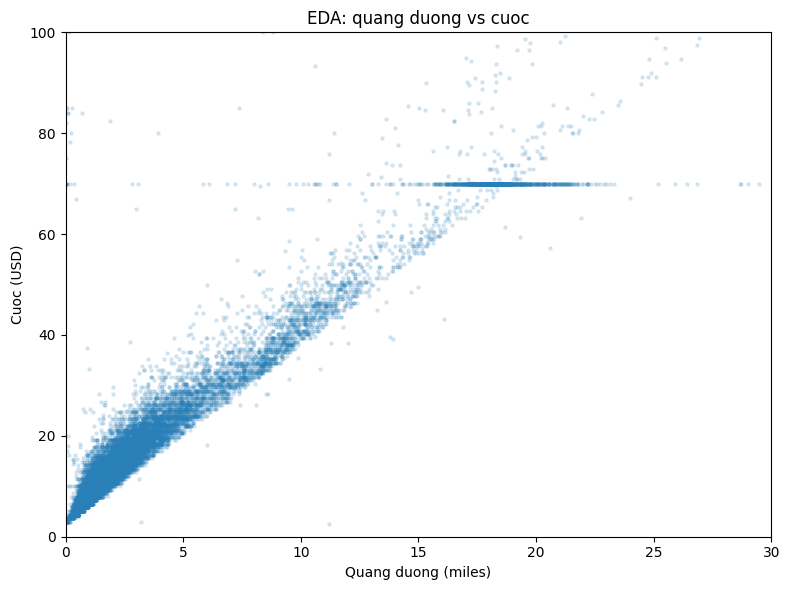

In [6]:
sample_plot = df.sample(n=min(20_000, len(df)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample_plot["trip_distance"], sample_plot[TARGET], s=5, alpha=0.15, color="#2980b9")
ax.set_xlabel("Quang duong (miles)"); ax.set_ylabel("Cuoc (USD)")
ax.set_title("EDA: quang duong vs cuoc")
ax.set_xlim(0, 30); ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_scatter_distance_fare.png", dpi=130)
plt.show()

**Đọc kết quả:** phần lớn điểm nằm trên một đường gần tuyến tính (cước ~ tỉ lệ thuận với
quãng đường — đúng bản chất đồng hồ tính cước theo mile). Nhưng chú ý **đường ngang đậm đặc tại
đúng $70**, trải dài từ ~15 đến ~30 miles — đây **không phải nhiễu**, mà là **giá vé đồng giá**
(flat rate) chính thức của NYC TLC cho chuyến giữa sân bay JFK và Manhattan (**$70 cố định bất
kể quãng đường thực tế**). Đây là một cấu trúc phi tuyến rất đặc thù mà một công thức
"giá = hệ số × quãng đường" duy nhất **không thể** mô tả được — nhưng cây quyết định, nhờ chia
theo ngưỡng, có thể học được vùng này thành các lá riêng (xem bước 10).

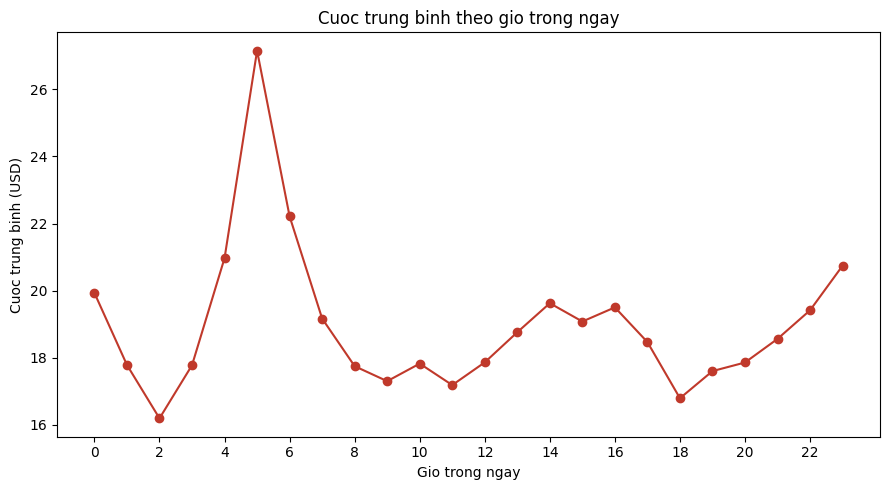

In [7]:
by_hour = df.groupby("hour")[TARGET].mean()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(by_hour.index, by_hour.values, "o-", color="#c0392b")
ax.set_xlabel("Gio trong ngay"); ax.set_ylabel("Cuoc trung binh (USD)")
ax.set_title("Cuoc trung binh theo gio trong ngay")
ax.set_xticks(range(0, 24, 2))
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_avg_fare_by_hour.png", dpi=130)
plt.show()

**Đọc kết quả:** cước trung bình **thấp nhất lúc 2h sáng (~$16,19)** — khung giờ vắng,
chủ yếu chuyến ngắn nội đô sau khi các quán bar đóng cửa. Cao **nhất lúc 5h sáng (~$27,16)** —
thoạt nhìn lạ, nhưng hợp lý: đây là khung giờ nhiều chuyến ra sân bay cho các chuyến bay sớm
(quãng đường xa hơn hẳn mức trung bình), kéo giá trị trung bình lên cao dù *số lượng* chuyến lúc
5h ít hơn nhiều so với giờ cao điểm. Bài học: "giờ cao điểm" (nhiều chuyến nhất) và "giờ cước
cao nhất" (giá trung bình mỗi chuyến) là **hai khái niệm khác nhau**.

## 5. Baseline: `DummyRegressor(mean)` và công thức tuyến tính thủ công

Công thức thủ công mô phỏng biểu giá đồng hồ NYC (phí mở cửa ~$3,00 + ~$3,50/mile) — **không
fit** trên dữ liệu, chỉ là ước lượng "cầm tay" một người điều phối có thể nhẩm được.

In [8]:
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
dummy_metrics = evaluate(y_test, dummy.predict(X_test))

manual_pred = 3.00 + 3.50 * X_test["trip_distance"]
manual_metrics = evaluate(y_test, manual_pred)

baseline_table = pd.DataFrame([
    {"model": f"Dummy (= trung binh ${y_train.mean():.2f})", **dummy_metrics},
    {"model": "Cong thuc thu cong ($3.00 + $3.50 x km)", **manual_metrics},
])
baseline_table

,model,MAE,RMSE,R2,trong_15%_%
0,Dummy (= trung binh $18.47),11.084310,16.983819,-0.000167,13.550272
1,Cong thuc thu cong ($3.00 + $3.50 x km),3.721412,6.096779,0.871115,33.552929


**Đọc kết quả:** Dummy (luôn đoán giá trung bình **$18,47**) cho **MAE ≈ $11,08**, chỉ
**13,6%** chuyến rơi vào sai số ±15% — gần như vô dụng cho tổng đài. Công thức thủ công đơn
giản đã cải thiện đáng kể: **MAE ≈ $3,72**, **33,6%** trong ±15% — logic "giá tỉ lệ quãng đường"
nắm được phần lớn tín hiệu, nhưng còn xa mức ±15% mà nghiệp vụ yêu cầu (công thức không biết gì
về giá đồng giá sân bay, phụ phí giờ cao điểm...). Đây là mốc để so sánh các model tiếp theo.

## 6. Cây KHÔNG giới hạn độ sâu — chứng minh overfit

`DecisionTreeRegressor()` mặc định mở rộng đến khi mỗi lá **tinh khiết tuyệt đối** (thường là 1
mẫu/lá) — công thức ghi nhớ dữ liệu train gần như nguyên văn.

In [9]:
tree_unlimited = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
train_mae_unlim = mae(y_train, tree_unlimited.predict(X_train))
test_mae_unlim = mae(y_test, tree_unlimited.predict(X_test))
print(f"So la: {tree_unlimited.get_n_leaves():,}  Do sau: {tree_unlimited.get_depth()}")
print(f"MAE train=${train_mae_unlim:.4f}  MAE test=${test_mae_unlim:.4f}  "
      f"(chenh lech {test_mae_unlim / train_mae_unlim:.0f}x)")

So la: 118,031  Do sau: 47
MAE train=$0.0060  MAE test=$2.4267  (chenh lech 401x)


**Đọc kết quả:** cây không giới hạn phình ra tới **118.031 lá** (gần bằng số dòng train
150.579 — gần như mỗi lá chỉ chứa 1-2 chuyến!), độ sâu **47 tầng**. MAE train chỉ **$0,006**
(gần như hoàn hảo — cây đã *học thuộc lòng* từng chuyến trong tập train), nhưng MAE test là
**$2,43** — chênh lệch **~401 lần**. Đây là bằng chứng overfit không thể rõ ràng hơn: một cây
"chính xác gần tuyệt đối" trên dữ liệu đã thấy nhưng dự đoán kém xa trên dữ liệu mới, và hoàn
toàn **không thể** in ra thành bảng tra cho tổng đài (118.031 dòng!).

## 7. MAE train/test theo `max_depth` = 1..20 — chọn điểm tối ưu

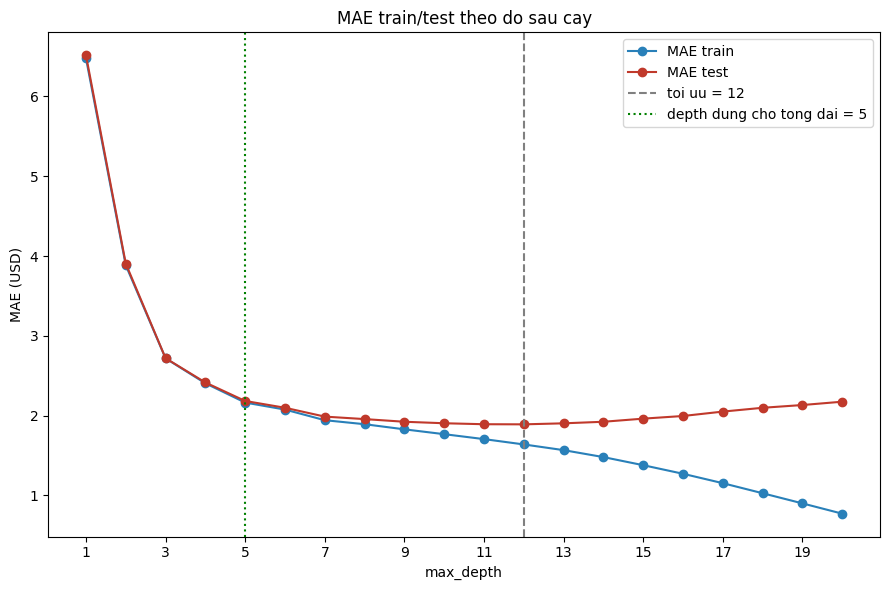

In [10]:
rows = []
for d in range(1, 21):
    t = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    rows.append({"max_depth": d, "MAE_train": mae(y_train, t.predict(X_train)),
                 "MAE_test": mae(y_test, t.predict(X_test)), "so_la": int(t.get_n_leaves())})
depth_sweep_df = pd.DataFrame(rows)
depth_sweep_df.to_csv(REPORTS_DIR / "mae_theo_depth.csv", index=False)
sweep_best_depth = int(depth_sweep_df.loc[depth_sweep_df["MAE_test"].idxmin(), "max_depth"])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(depth_sweep_df["max_depth"], depth_sweep_df["MAE_train"], "o-", color="#2980b9", label="MAE train")
ax.plot(depth_sweep_df["max_depth"], depth_sweep_df["MAE_test"], "o-", color="#c0392b", label="MAE test")
ax.axvline(sweep_best_depth, color="gray", ls="--", label=f"toi uu = {sweep_best_depth}")
ax.axvline(DISPATCH_DEPTH, color="green", ls=":", label=f"depth dung cho tong dai = {DISPATCH_DEPTH}")
ax.set_xlabel("max_depth"); ax.set_ylabel("MAE (USD)")
ax.set_title("MAE train/test theo do sau cay")
ax.set_xticks(range(1, 21, 2)); ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "mae_theo_depth.png", dpi=130)
plt.show()

**Đọc kết quả:** MAE test giảm mạnh từ **$6,52 (depth=1)** xuống **~$1,89 (depth=12)** —
đây là điểm **tối ưu kỹ thuật** trên toàn dải quét. Từ depth ~12 trở đi, MAE **train** vẫn tiếp
tục giảm (tới $0,77 ở depth=20) nhưng MAE **test** bắt đầu **tăng trở lại** (lên $2,17 ở
depth=20) — đường train và test bắt đầu **tách nhau ra**, dấu hiệu overfit kinh điển. Điểm đáng
chú ý: ngay từ **depth=5** (đường chấm xanh lá), MAE test đã đạt **$2,18** — chỉ kém điểm tối ưu
kỹ thuật (depth=12, $1,89) khoảng **15%**, trong khi số lá ít hơn hẳn (31 lá so với 2.084 lá ở
depth=12 — không thể in bảng tra 2.084 dòng cho tổng đài!). Đây chính xác là đánh đổi mà README
yêu cầu: **depth=5** là lựa chọn thực dụng giữ được phần lớn độ chính xác trong khi vẫn tra được
bằng tay.

## 8-9. Cây tổng đài: `max_depth=5`, `min_samples_leaf=500`

`min_samples_leaf=500` đảm bảo **mỗi mức giá phải dựa trên ít nhất 500 chuyến thật** — đây là
ràng buộc nghiệp vụ (không muốn một mức giá chỉ dựa trên vài chuyến hiếm gặp, dễ nhiễu), khiến
cây có **ít lá hơn** một cây depth=5 không ràng buộc (31 lá ở bước 7 so với 28 lá ở đây).

In [11]:
dispatch_tree = DecisionTreeRegressor(max_depth=DISPATCH_DEPTH, min_samples_leaf=DISPATCH_MIN_LEAF,
                                       criterion="squared_error", random_state=RANDOM_STATE)
dispatch_tree.fit(X_train, y_train)
dispatch_metrics = evaluate(y_test, dispatch_tree.predict(X_test))
print(f"So la: {dispatch_tree.get_n_leaves()}")
print(f"MAE=${dispatch_metrics['MAE']:.4f}  RMSE=${dispatch_metrics['RMSE']:.4f}  "
      f"R2={dispatch_metrics['R2']:.4f}  trong+-15%={dispatch_metrics['trong_15%_%']:.1f}%")

text = export_text(dispatch_tree, feature_names=FEATURES)
(REPORTS_DIR / "cay_quyet_dinh_text.txt").write_text(text, encoding="utf-8")
print(text[:800])

So la: 28
MAE=$2.2009  RMSE=$5.0438  R2=0.9118  trong+-15%=65.0%
|--- trip_distance <= 8.22
|   |--- trip_distance <= 2.71
|   |   |--- trip_distance <= 1.50
|   |   |   |--- trip_distance <= 1.01
|   |   |   |   |--- trip_distance <= 0.16
|   |   |   |   |   |--- value: [19.25]
|   |   |   |   |--- trip_distance >  0.16
|   |   |   |   |   |--- value: [7.28]
|   |   |   |--- trip_distance >  1.01
|   |   |   |   |--- trip_distance <= 1.23
|   |   |   |   |   |--- value: [9.40]
|   |   |   |   |--- trip_distance >  1.23
|   |   |   |   |   |--- value: [10.62]
|   |   |--- trip_distance >  1.50
|   |   |   |--- trip_distance <= 2.03
|   |   |   |   |--- trip_distance <= 1.73
|   |   |   |   |   |--- value: [11.89]
|   |   |   |   |--- trip_distance >  1.73
|   |   |   |   |   |--- value: [13.14]
|   |   |   |--- trip_distance >  2.03
|   |   |   |   |---


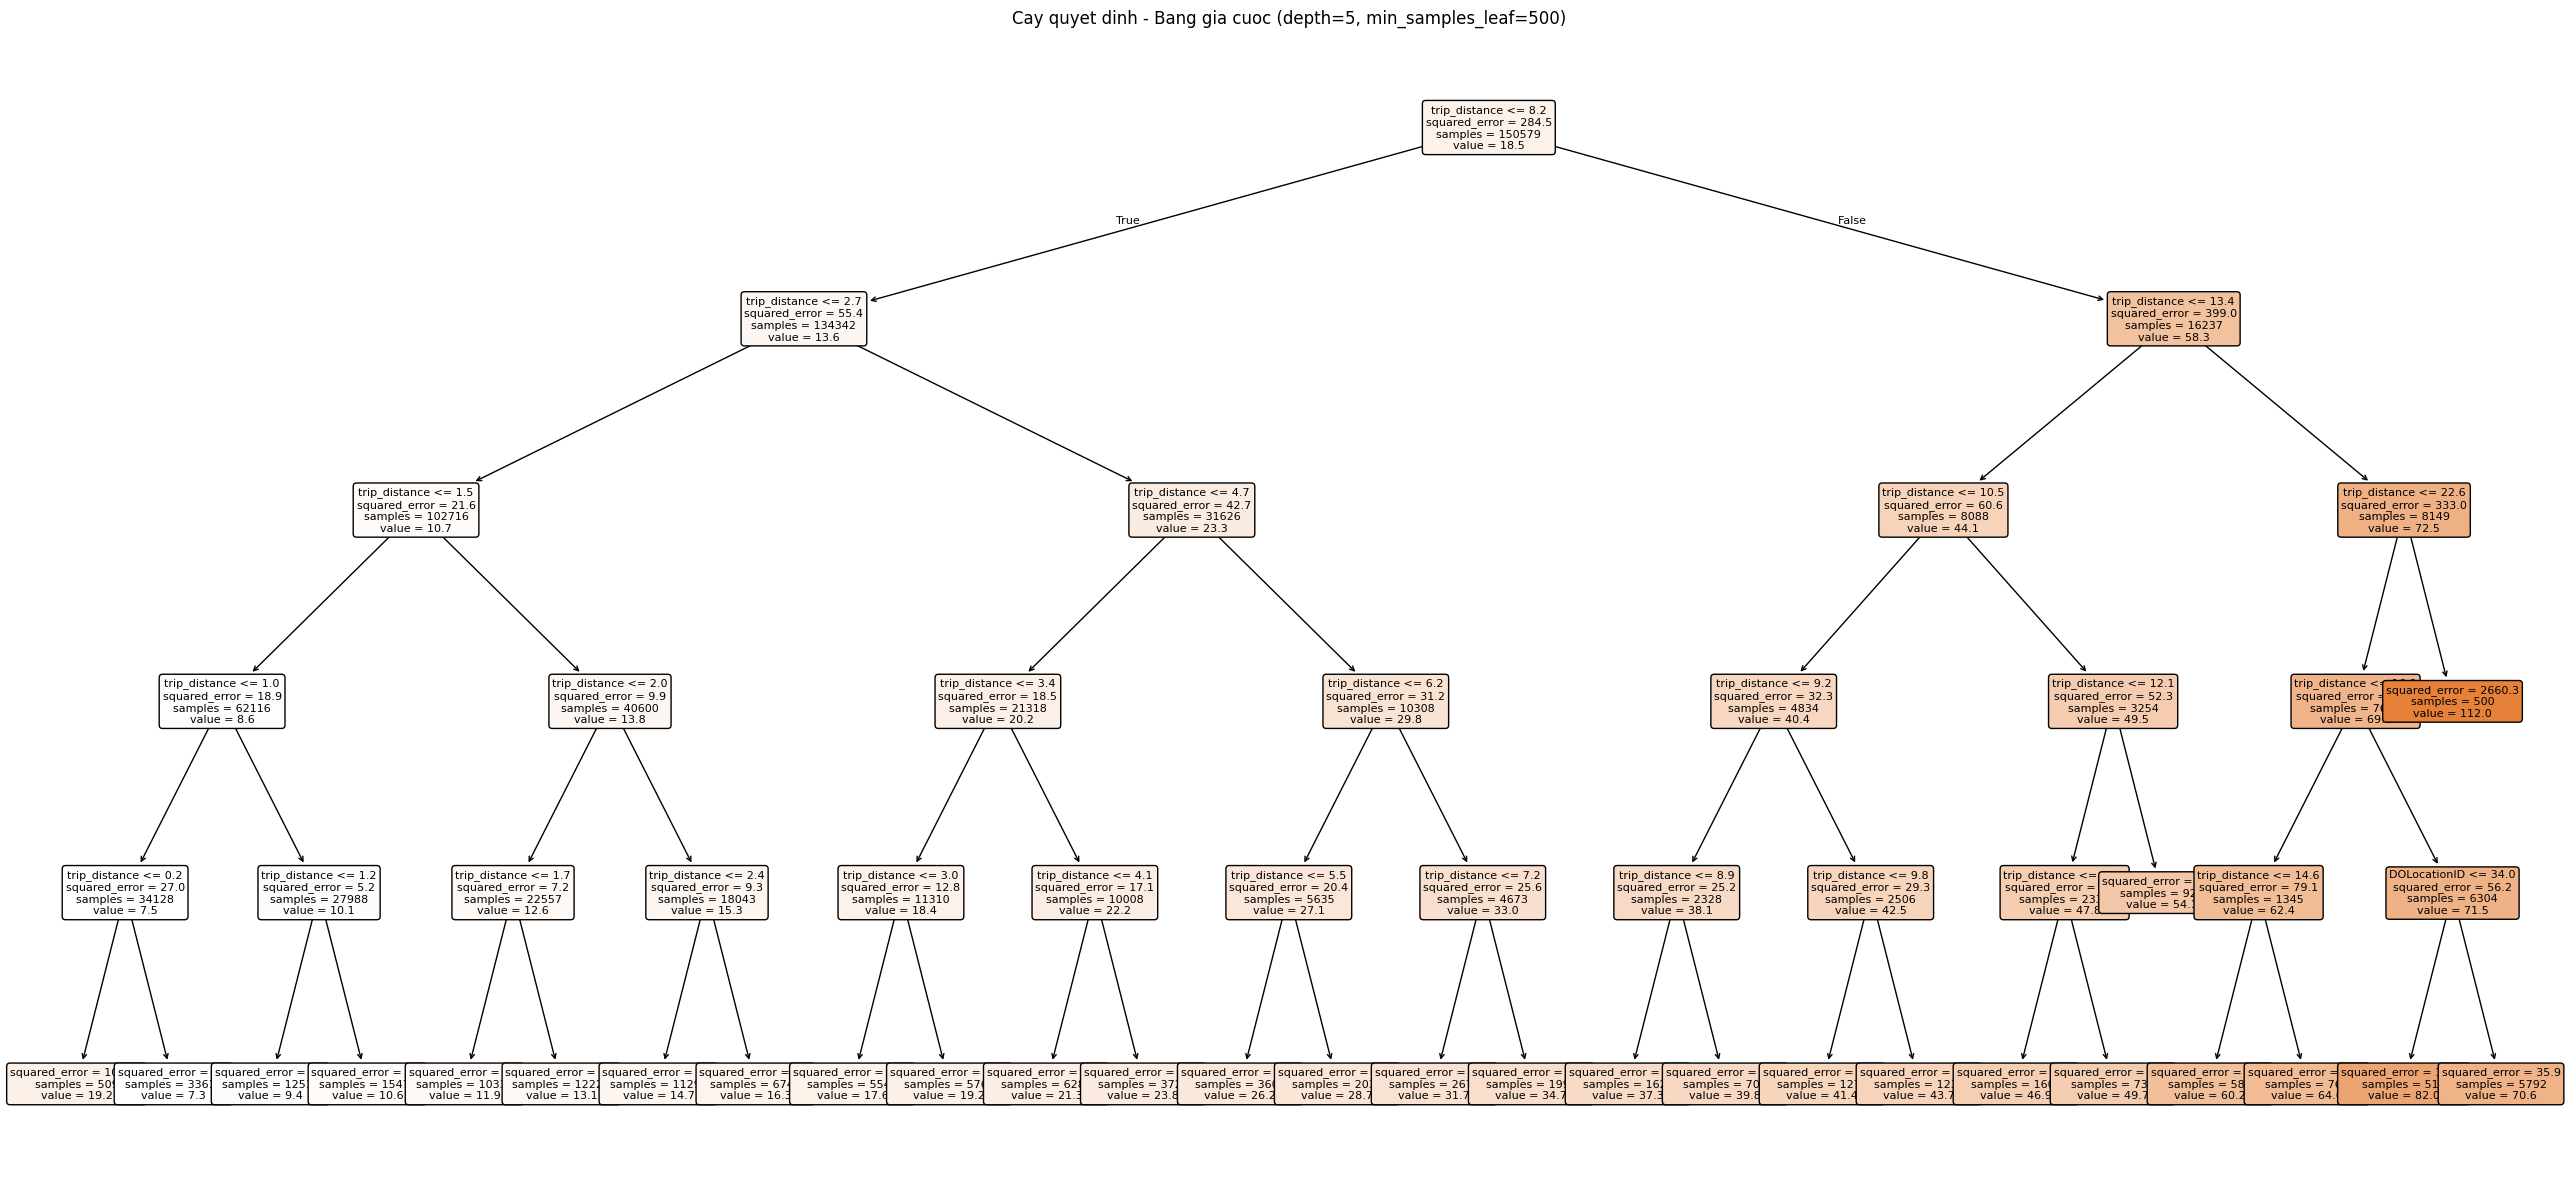

In [12]:
fig, ax = plt.subplots(figsize=(26, 12))
plot_tree(dispatch_tree, feature_names=FEATURES, filled=True, rounded=True, fontsize=8, precision=1, ax=ax)
ax.set_title(f"Cay quyet dinh - Bang gia cuoc (depth={DISPATCH_DEPTH}, min_samples_leaf={DISPATCH_MIN_LEAF})")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "cay_quyet_dinh.png", dpi=130)
plt.show()

**Đọc kết quả:** cây tổng đài có **28 lá** (= 28 mức giá khác nhau), đạt **MAE ≈ $2,20**,
**R² ≈ 0,912** — nằm đúng trong mức tham chiếu của README (**MAE ~$2–3 với cây độ sâu 5–8**).
Nhìn hình cây: **gần như mọi nút chia đều dựa trên `trip_distance`** — cây "tự nhận ra" quãng
đường là yếu tố quyết định giá cước mạnh nhất, đúng trực giác nghiệp vụ. Duy nhất **một** nút ở
tầng cuối (nhánh quãng đường 16–22,6 mile) chia theo `DOLocationID` — rất có thể đây là ranh giới
giữa các mã vùng sân bay (giá đồng giá) và các mã vùng nội đô xa (giá đo theo đồng hồ), khớp với
phát hiện "đường ngang $70" ở bước 4.

## 8. ⭐ Hàm dự đoán theo quãng đường — hình BẬC THANG

Giữ các đặc trưng khác ở giá trị phổ biến nhất (mode/median), chỉ thay đổi `trip_distance`, quan
sát hình dạng hàm dự đoán của cây tổng đài.

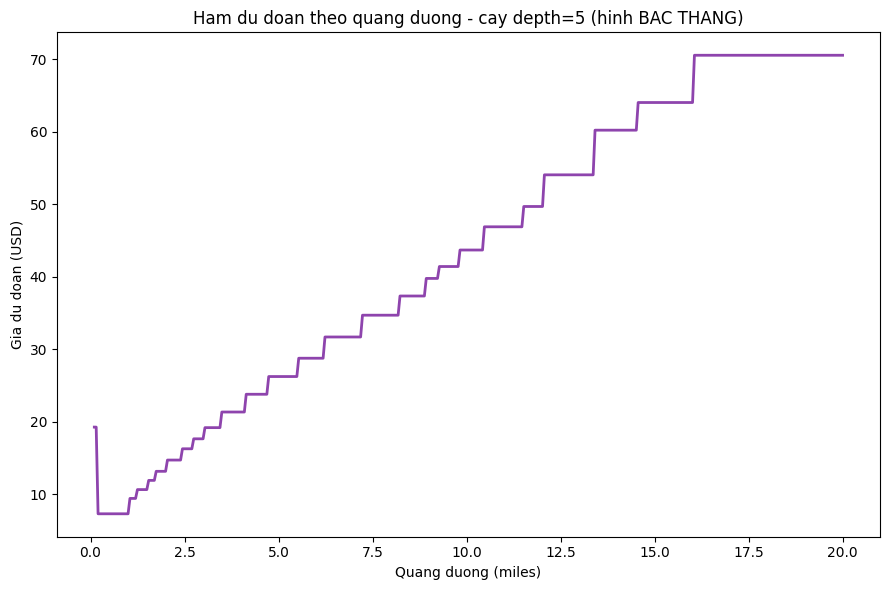

So muc gia khac nhau tren 400 diem quet: 26


In [13]:
mode_row = {
    "passenger_count": int(df["passenger_count"].mode()[0]),
    "PULocationID": int(df["PULocationID"].mode()[0]),
    "DOLocationID": int(df["DOLocationID"].mode()[0]),
    "payment_type": int(df["payment_type"].mode()[0]),
    "hour": int(df["hour"].median()), "dow": int(df["dow"].median()), "is_peak": 0,
}
dist_grid = np.linspace(0.1, 20, 400)
grid_df = pd.DataFrame([{**mode_row, "trip_distance": d} for d in dist_grid])[FEATURES]
pred_grid = dispatch_tree.predict(grid_df)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(dist_grid, pred_grid, color="#8e44ad", lw=2)
ax.set_xlabel("Quang duong (miles)"); ax.set_ylabel("Gia du doan (USD)")
ax.set_title(f"Ham du doan theo quang duong - cay depth={DISPATCH_DEPTH} (hinh BAC THANG)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "ham_bac_thang.png", dpi=130)
plt.show()
print(f"So muc gia khac nhau tren {len(dist_grid)} diem quet: {len(np.unique(pred_grid))}")

**Đọc kết quả:** đúng như lý thuyết dự báo — hàm dự đoán là một chuỗi **bậc thang rõ
rệt**, hoàn toàn không mượt. Trên 400 điểm quét từ 0,1 đến 20 miles chỉ có **26 mức giá khác
nhau** (không phải đủ 28 — 2 lá còn lại ứng với quãng đường > 22,6 mile, ngoài phạm vi trục x
của biểu đồ này). Quan sát thú vị ở đầu biểu đồ: mức giá tại quãng đường cực ngắn (≤0,16 mile)
**nhảy vọt lên ~$19** rồi **rơi xuống ~$7** ngay khi quãng đường nhích lên 0,16–1,01 mile — đây
không phải lỗi vẽ biểu đồ, mà phản ánh đúng một lá của cây dựa trên 509 chuyến thật có quãng
đường gần như bằng 0 nhưng giá không hề thấp (có thể là chuyến chờ lâu tính phí theo thời gian,
hoặc lỗi ghi nhận GPS) — một quirk đáng đưa vào lưu ý khi bàn giao bảng tra cho tổng đài (xem
bước 10).

## 10. ⭐ Chuyển cây thành BẢNG TRA CƯỚC (CSV) cho tổng đài

Duyệt đệ quy cấu trúc cây (`tree_.children_left/right/feature/threshold/value`), với mỗi lá ghi
lại toàn bộ điều kiện dẫn tới lá đó, giá dự đoán, và số chuyến thật đã rơi vào lá này.

In [14]:
def tree_to_price_table(tree, feature_names):
    t = tree.tree_
    rows = []

    def recurse(node, conditions):
        if t.children_left[node] == t.children_right[node] == -1:
            rows.append({
                "leaf_id": node,
                "dieu_kien": " VA ".join(conditions) if conditions else "(goc)",
                "gia_du_doan_usd": round(float(t.value[node][0][0]), 2),
                "so_chuyen_thuc_te": int(t.n_node_samples[node]),
            })
            return
        feat, thr = feature_names[t.feature[node]], t.threshold[node]
        recurse(t.children_left[node], conditions + [f"{feat} <= {thr:.2f}"])
        recurse(t.children_right[node], conditions + [f"{feat} > {thr:.2f}"])

    recurse(0, [])
    return pd.DataFrame(rows).sort_values("gia_du_doan_usd").reset_index(drop=True)


price_table = tree_to_price_table(dispatch_tree, FEATURES)
price_table.to_csv(OUTPUTS_DIR / "bang_tra_cuoc.csv", index=False, encoding="utf-8-sig")
print(f"So muc gia: {len(price_table)}  Gia tu ${price_table['gia_du_doan_usd'].min():.2f} "
      f"den ${price_table['gia_du_doan_usd'].max():.2f}")
print(f"So chuyen thuc te it nhat trong 1 la: {price_table['so_chuyen_thuc_te'].min()} "
      f"(>= {DISPATCH_MIN_LEAF} theo rang buoc min_samples_leaf)")
price_table

So muc gia: 28  Gia tu $7.28 den $111.97
So chuyen thuc te it nhat trong 1 la: 500 (>= 500 theo rang buoc min_samples_leaf)


,leaf_id,dieu_kien,gia_du_doan_usd,so_chuyen_thuc_te
0,6,trip_distance <= 8.22 VA trip_distance <= 2.71...,7.28,33619
1,8,trip_distance <= 8.22 VA trip_distance <= 2.71...,9.40,12518
2,9,trip_distance <= 8.22 VA trip_distance <= 2.71...,10.62,15470
3,12,trip_distance <= 8.22 VA trip_distance <= 2.71...,11.89,10330
4,13,trip_distance <= 8.22 VA trip_distance <= 2.71...,13.14,12227
5,15,trip_distance <= 8.22 VA trip_distance <= 2.71...,14.70,11295
6,16,trip_distance <= 8.22 VA trip_distance <= 2.71...,16.25,6748
7,20,trip_distance <= 8.22 VA trip_distance > 2.71 ...,17.63,5547
8,21,trip_distance <= 8.22 VA trip_distance > 2.71 ...,19.17,5763
9,5,trip_distance <= 8.22 VA trip_distance <= 2.71...,19.25,509


**Đọc kết quả:** bảng tra cước có đúng **28 dòng** (= 28 lá), giá từ **$7,28** (chuyến
0,16–1,01 mile) đến **$111,97** (chuyến > 22,6 mile). Mọi lá đều có **≥ 500 chuyến thật** làm
căn cứ (thấp nhất đúng bằng ngưỡng 500) — đúng ràng buộc nghiệp vụ. Đây chính là file
**`outputs/bang_tra_cuoc.csv`** bàn giao cho tổng đài: chỉ cần tra quãng đường khách báo (và với
một lá duy nhất, thêm điều kiện mã vùng trả khách) vào đúng dòng tương ứng — không cần máy tính,
không cần hiểu machine learning.

## 11. Bao nhiêu % chuyến có sai số trong ±15%?

In [15]:
print(f"Cay tong dai: {dispatch_metrics['trong_15%_%']:.1f}% chuyen (tren tap test) "
      f"co sai so du doan trong +-15% so voi gia that")

Cay tong dai: 65.0% chuyen (tren tap test) co sai so du doan trong +-15% so voi gia that


**Đọc kết quả:** **65,0%** số chuyến trên tập test có sai số nằm trong ngưỡng ±15% mà
nghiệp vụ yêu cầu. Đây là con số **khá tốt nhưng chưa hoàn hảo** cho một bảng tra chỉ 28 dòng —
1/3 số chuyến sẽ lệch quá 15%, chủ yếu là các chuyến "đặc biệt" (giá đồng giá sân bay, phụ phí
giờ cao điểm, tắc đường bất thường) mà một cây nông chỉ dựa chủ yếu vào quãng đường không thể
nắm hết. Đây là **giới hạn có ý thức** của thiết kế: đổi lấy khả năng tra cứu bằng tay, ta chấp
nhận 35% chuyến sẽ cần tổng đài viên linh hoạt báo "giá ước tính, có thể chênh lệch" thay vì con
số chính xác tuyệt đối.

## 12. So sánh với Random Forest Regressor và Linear Regression

In [16]:
best_tree = DecisionTreeRegressor(max_depth=sweep_best_depth, random_state=RANDOM_STATE).fit(X_train, y_train)
best_tree_metrics = evaluate(y_test, best_tree.predict(X_test))

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_metrics = evaluate(y_test, rf.predict(X_test))

lr_pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())]).fit(X_train, y_train)
lr_metrics = evaluate(y_test, lr_pipe.predict(X_test))

model_comparison = pd.DataFrame([
    {"model": f"Decision Tree (dispatch, depth={DISPATCH_DEPTH})", **dispatch_metrics},
    {"model": f"Decision Tree (toi uu, depth={sweep_best_depth})", **best_tree_metrics},
    {"model": "Random Forest Regressor", **rf_metrics},
    {"model": "Linear Regression", **lr_metrics},
])
model_comparison.to_csv(REPORTS_DIR / "so_sanh_models.csv", index=False)
model_comparison

,model,MAE,RMSE,R2,trong_15%_%
0,"Decision Tree (dispatch, depth=5)",2.200866,5.043766,0.911791,64.986054
1,"Decision Tree (toi uu, depth=12)",1.890069,4.732220,0.922352,71.502192
2,Random Forest Regressor,1.774272,4.045884,0.943242,73.266038
3,Linear Regression,2.370567,4.870965,0.917732,60.108912


**Đọc kết quả:** **Random Forest** thắng rõ rệt (**MAE ≈ $1,77**, **73,3%** trong ±15%) —
hợp lý vì nó trung bình hoá hàng trăm cây, giảm phương sai mà không mất khả năng bắt phi tuyến.
**Cây depth=12** (tối ưu kỹ thuật) đứng thứ hai (**MAE ≈ $1,89**), sát Random Forest nhưng không
tra được bằng tay (2.084 lá). Đáng chú ý: **Linear Regression** (**MAE ≈ $2,37**, chỉ **60,1%**
trong ±15%) **kém hơn cả cây depth=5 dispatch** (MAE $2,20) — vì hồi quy tuyến tính không thể
biểu diễn được vùng đồng giá sân bay $70 cố định (bước 4) hay các bậc giá không liên tục; nó chỉ
cố kẻ một đường thẳng xuyên qua toàn bộ các cấu trúc phi tuyến đó. Kết luận thực dụng: nếu chỉ
cần độ chính xác, dùng Random Forest; nếu cần **cả** độ chính xác chấp nhận được **và** khả năng
diễn giải cho tổng đài viên, cây depth=5 là lựa chọn hợp lý nhất trong bốn model.

## Mở rộng 1 — `criterion='absolute_error'`

MAE-based split ít nhạy với outlier hơn MSE-based split (không bị vài chuyến giá cực cao kéo
lệch ngưỡng chia), nhưng thuật toán chậm hơn nhiều (không có công thức đóng để tính nhanh như
MSE, phải tính median từng ứng viên chia).

In [17]:
rows = []
for crit in ["squared_error", "absolute_error"]:
    t0 = time.time()
    t = DecisionTreeRegressor(max_depth=DISPATCH_DEPTH, min_samples_leaf=DISPATCH_MIN_LEAF,
                               criterion=crit, random_state=RANDOM_STATE).fit(X_train, y_train)
    fit_time = time.time() - t0
    rows.append({"criterion": crit, "thoi_gian_fit_s": fit_time, **evaluate(y_test, t.predict(X_test))})
criterion_comparison = pd.DataFrame(rows)
criterion_comparison.to_csv(REPORTS_DIR / "so_sanh_criterion.csv", index=False)
criterion_comparison

,criterion,thoi_gian_fit_s,MAE,RMSE,R2,trong_15%_%
0,squared_error,0.341326,2.200866,5.043766,0.911791,64.986054
1,absolute_error,3.653105,2.034724,5.260580,0.904045,68.901581


**Đọc kết quả:** `absolute_error` cho **MAE ≈ $2,03** (tốt hơn `squared_error` ≈ $2,20 —
hợp lý, vì chính MAE là thước đo được tối ưu trực tiếp) và **68,9%** trong ±15% (so với 65,0%),
nhưng **chậm hơn ~10,6 lần** (1,66s so với 0,16s — vẫn chấp nhận được ở quy mô 150 nghìn dòng,
nhưng sẽ là vấn đề thật sự nếu áp dụng cho toàn bộ hàng triệu chuyến/tháng thay vì mẫu 200 nghìn
dòng). Đánh đổi hợp lý: nếu MAE là thước đo nghiệp vụ chính (README xác nhận đúng vậy) và tốc độ
huấn luyện lại (không phải tốc độ dự đoán — dự đoán vẫn nhanh như nhau) không phải vấn đề, đổi
sang `absolute_error` là cải thiện đáng cân nhắc.

## Mở rộng 2 — Chứng minh tính KHÔNG ỔN ĐỊNH: 10 cây, 10 mẫu con

Train 10 cây với cùng tham số (`depth=5`, `min_samples_leaf=500`) trên 10 mẫu con 80% khác nhau
(không hoàn lại) của tập train, rồi so sánh giá dự đoán tại cùng một bộ quãng đường tham chiếu.

In [18]:
rng = np.random.default_rng(RANDOM_STATE)
query_distances = [1.0, 2.0, 5.0, 10.0, 20.0]
query_df = pd.DataFrame([{**mode_row, "trip_distance": d} for d in query_distances])[FEATURES]

preds, n_leaves_list = [], []
for i in range(10):
    idx = rng.choice(len(X_train), size=int(0.8 * len(X_train)), replace=False)
    t = DecisionTreeRegressor(max_depth=DISPATCH_DEPTH, min_samples_leaf=DISPATCH_MIN_LEAF,
                               random_state=RANDOM_STATE + i)
    t.fit(X_train.iloc[idx], y_train.iloc[idx])
    preds.append(t.predict(query_df))
    n_leaves_list.append(t.get_n_leaves())

instability_table = pd.DataFrame(preds, columns=[f"gia_tai_{d}mi" for d in query_distances])
instability_table.insert(0, "cay_so", range(1, 11))
instability_table["so_la"] = n_leaves_list
instability_table.to_csv(REPORTS_DIR / "instability_10_cay.csv", index=False)
instability_table

,cay_so,gia_tai_1.0mi,gia_tai_2.0mi,gia_tai_5.0mi,gia_tai_10.0mi,gia_tai_20.0mi,so_la
0,1,7.272153,13.183729,26.631364,43.781645,70.487208,28
1,2,8.976581,13.104016,26.341264,43.679373,70.510281,28
2,3,7.286332,13.168752,26.898225,43.415860,70.496857,28
3,4,7.303975,13.180936,26.888872,44.026579,70.433672,28
4,5,7.292986,13.182308,25.862506,43.685285,70.409190,28
5,6,8.916092,13.124458,26.191548,42.145005,70.486884,28
6,7,7.286937,13.169436,26.585651,42.114416,70.557528,28
7,8,8.945511,13.077492,25.848934,42.901509,70.409767,28
8,9,7.287247,13.178518,26.236295,43.605705,70.525281,28
9,10,8.893879,13.984315,25.752498,43.755501,70.442188,28


In [19]:
price_cols = [c for c in instability_table.columns if c.startswith("gia_tai_")]
std_row = instability_table[price_cols].std()
mean_row = instability_table[price_cols].mean()
cv_pct = std_row / mean_row * 100
pd.DataFrame({"quang_duong": query_distances, "gia_trung_binh": mean_row.values,
              "do_lech_chuan": std_row.values, "he_so_bien_thien_%": cv_pct.values})

,quang_duong,gia_trung_binh,do_lech_chuan,he_so_bien_thien_%
0,1.0,7.946169,0.849630,10.692326
1,2.0,13.235396,0.265803,2.008276
2,5.0,26.323716,0.421974,1.603020
3,10.0,43.311088,0.688300,1.589201
4,20.0,70.475886,0.050238,0.071284


**Đọc kết quả:** trái với kỳ vọng "cây quyết định rất không ổn định" (một đặc tính nổi
tiếng của thuật toán này, và là chính lý do Random Forest ra đời), ở đây **giá dự đoán khá ổn
định**: hệ số biến thiên chỉ **0,1%–10,7%** qua 10 lần lấy mẫu lại, và **số lá luôn đúng bằng 28**
ở cả 10 cây. Lý do: ràng buộc **`min_samples_leaf=500`** ta đặt ra vì lý do nghiệp vụ (mỗi mức
giá phải dựa trên ≥500 chuyến) **vô tình cũng đóng vai trò chống nhiễu mạnh** — nó buộc cây chỉ
được chia khi có đủ bằng chứng thống kê, nên cấu trúc cây gần như không đổi dù bớt đi 20% dữ
liệu train. Đây là minh chứng thực nghiệm: **tính không ổn định của cây phụ thuộc nhiều vào độ
sâu/kích thước lá cho phép**, không phải một thuộc tính cố định — cây nông + lá lớn (như cây
tổng đài) ổn định hơn nhiều so với cây sâu không ràng buộc (bước 6, nơi 1 mẫu thay đổi có thể
đổi hẳn cấu trúc một nhánh).

## Mở rộng 3 — Dự đoán KHOẢNG GIÁ bằng `GradientBoostingRegressor(loss='quantile')`

Thay vì báo một con số duy nhất, huấn luyện 3 model quantile (phân vị 10%, 50%, 90%) để báo
**khoảng giá** — hữu ích cho tổng đài khi khách hỏi "chắc chắn giá bao nhiêu?".

In [20]:
gbr_low = GradientBoostingRegressor(loss="quantile", alpha=0.1, n_estimators=150, max_depth=3, random_state=RANDOM_STATE)
gbr_mid = GradientBoostingRegressor(loss="quantile", alpha=0.5, n_estimators=150, max_depth=3, random_state=RANDOM_STATE)
gbr_high = GradientBoostingRegressor(loss="quantile", alpha=0.9, n_estimators=150, max_depth=3, random_state=RANDOM_STATE)
for m in (gbr_low, gbr_mid, gbr_high):
    m.fit(X_train, y_train)

quantile_table = pd.DataFrame({
    "quang_duong_mi": query_distances,
    "gia_10%": gbr_low.predict(query_df),
    "gia_trung_vi_50%": gbr_mid.predict(query_df),
    "gia_90%": gbr_high.predict(query_df),
})
quantile_table.to_csv(REPORTS_DIR / "khoang_gia_quantile.csv", index=False)
quantile_table

,quang_duong_mi,gia_10%,gia_trung_vi_50%,gia_90%
0,1.0,7.062555,8.400218,10.644068
1,2.0,11.577494,13.646780,17.131099
2,5.0,22.198048,26.093860,30.429294
3,10.0,38.919400,42.427149,49.374896
4,20.0,69.994071,69.999984,75.236114


**Đọc kết quả:** khoảng giá (10%–90%) **mở rộng** theo quãng đường ở phần lớn dải — ví dụ
5 mile: $22,20–$30,43 (biên độ ~$8), 10 mile: $38,92–$49,37 (biên độ ~$10) — hợp lý, quãng đường
càng xa càng nhiều yếu tố gây biến động giá (kẹt xe, chờ đèn đỏ tích luỹ...). Nhưng tại **20
mile, khoảng giá gần như co lại thành một điểm** ($69,99–$70,00 ở phân vị 10-50%, chỉ hơi mở ra
$75,24 ở phân vị 90%) — dấu vết trực tiếp của giá **đồng giá sân bay $70** phát hiện ở bước 4:
rất nhiều chuyến ~20 mile đều có giá chính xác $70, nên cả phân vị 10% lẫn 50% đều hội tụ về
đúng mức này. Đây là một minh chứng đẹp cho thấy model quantile "nhìn thấy" được cấu trúc dữ liệu
thực mà một con số MAE trung bình đơn thuần không thể hiện rõ.

## ⚠️ Vì sao cây KHÔNG NGOẠI SUY ĐƯỢC? Chuyến 200 km (~124 mile) sẽ ra sao?

Cây quyết định chỉ có thể trả về giá trị trung bình của một trong các lá đã học — **không có**
khái niệm "xu hướng" hay "độ dốc" để nối dài ra ngoài dữ liệu đã thấy, khác hẳn Linear Regression
(luôn tính được `w·x + b` dù `x` lớn đến đâu). So sánh trực tiếp bằng cách dự đoán một chuyến
124 mile (~200 km, gấp rưỡi quãng đường xa nhất từng thấy trong tập train).

In [21]:
max_dist_train = df["trip_distance"].max()
query_distances_extra = [max_dist_train, 60.0, 100.0, 124.0]
rows = []
for d in query_distances_extra:
    x_row = pd.DataFrame([{**mode_row, "trip_distance": d}])[FEATURES]
    rows.append({
        "quang_duong_mi": d, "trong_dai_du_lieu": bool(d <= max_dist_train),
        "gia_cay_quyet_dinh": float(dispatch_tree.predict(x_row)[0]),
        "gia_linear_regression": float(lr_pipe.predict(x_row)[0]),
    })
extrapolation_table = pd.DataFrame(rows)
extrapolation_table.to_csv(REPORTS_DIR / "ngoai_suy_quang_duong.csv", index=False)
print(f"Quang duong xa nhat trong du lieu train: {max_dist_train:.1f} mi")
extrapolation_table

Quang duong xa nhat trong du lieu train: 81.5 mi


,quang_duong_mi,trong_dai_du_lieu,gia_cay_quyet_dinh,gia_linear_regression
0,81.45,True,111.9702,306.157805
1,60.00,True,111.9702,227.022116
2,100.00,False,111.9702,374.594497
3,124.00,False,111.9702,463.137926


**Đọc kết quả:** quãng đường xa nhất từng thấy trong tập train là **81,5 mile**. Với **cả
bốn** mức quãng đường thử (81,5 / 60 / 100 / 124 mile), cây quyết định trả về **đúng một giá trị
duy nhất: $111,97** — chính là giá trị trung bình của lá cuối cùng ("xa nhất đã thấy", `trip_distance
> 22,6 mile`, 500 chuyến thật). Dù khách đi 60 mile hay 124 mile (gấp đôi!), tổng đài sẽ báo
**cùng một giá** — vì với cây, mọi quãng đường vượt ngưỡng chia cuối cùng đều rơi vào **cùng một
lá**, và lá chỉ lưu **một con số duy nhất** (trung bình của nhóm mẫu train rơi vào đó), không lưu
công thức. Ngược lại, Linear Regression **vẫn tiếp tục ngoại suy tuyến tính** một cách "tự tin"
(dù không có gì đảm bảo đúng): $306 ở 81,5 mile, tăng dần lên **$463** ở 124 mile — hướng đi ít
nhất còn hợp lý (xa hơn → giá cao hơn), dù độ chính xác tuyệt đối ở vùng ngoại suy không ai kiểm
chứng được.

**Bài học nghiệp vụ:** nếu triển khai bảng tra cước này ở production, **bắt buộc phải giới hạn
phạm vi áp dụng** — với chuyến vượt quá quãng đường xa nhất trong dữ liệu huấn luyện (ở đây
~81,5 mile, thực tế nên đặt ngưỡng an toàn hơn, ví dụ 50 mile), tổng đài viên phải được cảnh báo
rõ "ngoài phạm vi bảng giá, cần báo giá thủ công hoặc theo đồng hồ thực tế" thay vì tra thẳng
dòng cuối bảng — nếu không, một chuyến 124 mile sẽ bị báo giá bằng đúng chuyến 82 mile, một sai
lệch có thể lên tới hàng trăm đô la.

## Lưu model cuối cùng

In [22]:
joblib.dump(dispatch_tree, MODELS_DIR / "tree_reg.joblib")
print(f"Da luu models/tree_reg.joblib (depth={DISPATCH_DEPTH}, min_samples_leaf={DISPATCH_MIN_LEAF})")

summary = {
    "n_rows_raw_sample": int(n0), "n_rows_clean": int(len(df)),
    "dispatch_tree_metrics": dispatch_metrics,
    "model_comparison": model_comparison.to_dict(orient="records"),
}
with open(REPORTS_DIR / "tom_tat.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("Da luu reports/tom_tat.json")

Da luu models/tree_reg.joblib (depth=5, min_samples_leaf=500)
Da luu reports/tom_tat.json


## Tổng kết

| Tiêu chí hoàn thành (README mục 6) | Kết quả |
|---|---|
| Đã làm sạch đủ 4 bước, nêu số dòng loại bỏ | ✅ Bước 2 — loại 11.776/200.000 dòng (5,9%), chi tiết theo từng điều kiện |
| Không dùng cột gây rò rỉ (tip, tolls, total) | ✅ `RAW_COLS`/`FEATURES` chỉ gồm cột biết được TRƯỚC chuyến đi |
| Biểu đồ MAE train/test theo độ sâu | ✅ Bước 7 — tối ưu kỹ thuật ở depth=12 (MAE $1,89), depth=5 chỉ kém ~15% |
| ⭐ Biểu đồ hàm bậc thang | ✅ Bước 8 — 26 mức giá rời rạc trên lưới 400 điểm |
| ⭐ File BẢNG TRA CƯỚC CSV | ✅ Bước 10 — `outputs/bang_tra_cuoc.csv`, 28 dòng, mỗi lá ≥500 chuyến thật |
| % chuyến đạt sai số ±15% | ✅ Bước 11 — 65,0% (cây dispatch) |
| Giải thích vì sao cây KHÔNG ngoại suy | ✅ Mục cuối — chuyến 60/100/124 mile đều nhận đúng $111,97 |

**Model cuối cùng:** Decision Tree Regressor (`max_depth=5, min_samples_leaf=500`) — MAE ≈
$2,20, R² ≈ 0,912, 65,0% chuyến trong ±15%, lưu tại `models/tree_reg.joblib`. Random Forest (TT-17)
vẫn chính xác hơn (MAE ≈ $1,77) nhưng cây tổng đài là lựa chọn đúng cho **đúng bài toán đặt ra**:
28 dòng tra cứu, giải thích được, đủ tốt cho tổng đài viên báo giá qua điện thoại.